In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mstfabihaafifa/2011-2012/SPX_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/OCQ_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/SMQ_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/CBC_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/RDQ_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/ENX_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/BMX_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/MCQ_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2011-2012/DEMO_G.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/SMQ_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/SPX_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/RDQ_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/BMX_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/DEMO_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/MCQ_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/CBC_F.xpt
/kaggle/input/datasets/mstfabihaafifa/2009-2010/ENX_F.xpt
/kaggle/inpu

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from xgboost import XGBClassifier
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CYCLES = ["E", "F", "G"]

FILES = [
    "DEMO",
    "BMX",
    "CBC",
    "ENX",
    "MCQ",
    "OCQ",
    "RDQ",
    "SMQ",
    "SPX"
]

KAGGLE_INPUT_ROOT = Path("/kaggle/input")

SEARCH_ROOT = (
    KAGGLE_INPUT_ROOT
    if KAGGLE_INPUT_ROOT.exists()
    else Path("/mnt/data")
)


def discover_nhanes_files(search_root=SEARCH_ROOT):

    file_map = {}

    for path in search_root.rglob("*"):

        if not path.is_file():
            continue

        if path.suffix.lower() != ".xpt":
            continue

        normalized_stem = re.sub(
            r"\(\d+\)$",
            "",
            path.stem.upper().replace(" ", "")
        )

        match = re.fullmatch(
            r"(DEMO|BMX|CBC|ENX|MCQ|OCQ|RDQ|SMQ|SPX)_([EFG])",
            normalized_stem
        )

        if not match:
            continue

        module, cycle = match.groups()

        key = (module, cycle)

        if key not in file_map or "(" not in path.stem:
            file_map[key] = path

    return file_map


XPT_FILE_MAP = discover_nhanes_files()

expected_keys = {
    (module, cycle)
    for cycle in CYCLES
    for module in FILES
}

missing_keys = sorted(
    expected_keys - set(XPT_FILE_MAP)
)

print("Search root:", SEARCH_ROOT)

print(
    f"Detected {len(XPT_FILE_MAP)} "
    f"of {len(expected_keys)} required XPT files."
)

for cycle in CYCLES:

    print(f"\nCycle {cycle}:")

    for module in FILES:

        path = XPT_FILE_MAP.get((module, cycle))

        if path:
            print(f"  {module}_{cycle}: {path.name}")
        else:
            print(f"  {module}_{cycle}: MISSING")


if missing_keys:

    missing_text = ", ".join(
        f"{module}_{cycle}"
        for module, cycle in missing_keys
    )

    raise FileNotFoundError(
        "The following required files were not found: "
        f"{missing_text}. "
        "Attach the Kaggle dataset containing all 27 XPT files."
    )

Search root: /kaggle/input
Detected 27 of 27 required XPT files.

Cycle E:
  DEMO_E: DEMO_E.xpt
  BMX_E: BMX_E.xpt
  CBC_E: CBC_E.xpt
  ENX_E: ENX_E.xpt
  MCQ_E: MCQ_E.xpt
  OCQ_E: OCQ_E.xpt
  RDQ_E: RDQ_E.xpt
  SMQ_E: SMQ_E.xpt
  SPX_E: SPX_E.xpt

Cycle F:
  DEMO_F: DEMO_F.xpt
  BMX_F: BMX_F.xpt
  CBC_F: CBC_F.xpt
  ENX_F: ENX_F.xpt
  MCQ_F: MCQ_F.xpt
  OCQ_F: OCQ_F.xpt
  RDQ_F: RDQ_F.xpt
  SMQ_F: SMQ_F.xpt
  SPX_F: SPX_F.xpt

Cycle G:
  DEMO_G: DEMO_G.xpt
  BMX_G: BMX_G.xpt
  CBC_G: CBC_G.xpt
  ENX_G: ENX_G.xpt
  MCQ_G: MCQ_G.xpt
  OCQ_G: OCQ_G.xpt
  RDQ_G: RDQ_G.xpt
  SMQ_G: SMQ_G.xpt
  SPX_G: SPX_G.xpt


In [3]:
def load_xpt(module, cycle):

    key = (module, cycle)

    if key not in XPT_FILE_MAP:
        raise FileNotFoundError(
            f"Could not locate {module}_{cycle}.xpt"
        )

    path = XPT_FILE_MAP[key]

    df = pd.read_sas(
        path,
        format="xport",
        encoding="latin-1"
    )

    df.columns = [
        str(column).strip().upper()
        for column in df.columns
    ]

    if "SEQN" not in df.columns:
        raise KeyError(
            f"SEQN is missing from {path.name}"
        )

    if df["SEQN"].duplicated().any():
        raise ValueError(
            f"{path.name} contains duplicate SEQN values"
        )

    return df


def load_cycle(cycle):

    print(f"\nLoading cycle {cycle}...")

    merged = load_xpt(
        "DEMO",
        cycle
    ).copy()

    for module in FILES[1:]:

        right = load_xpt(
            module,
            cycle
        ).copy()

        overlapping = [
            column
            for column in right.columns
            if column != "SEQN"
            and column in merged.columns
        ]

        if overlapping:

            right = right.rename(
                columns={
                    column: f"{column}_{module}"
                    for column in overlapping
                }
            )

            print(
                f"  {module}_{cycle}: renamed "
                f"{len(overlapping)} overlapping column(s)"
            )

        merged = merged.merge(
            right,
            on="SEQN",
            how="left",
            validate="one_to_one"
        )

        print(
            f"  Added {module}_{cycle}: "
            f"{merged.shape[0]:,} rows x "
            f"{merged.shape[1]:,} columns"
        )

    merged["CYCLE"] = cycle

    return merged


def build_merged(cycles=CYCLES):

    cycle_frames = [
        load_cycle(cycle)
        for cycle in cycles
    ]

    full = pd.concat(
        cycle_frames,
        axis=0,
        ignore_index=True,
        sort=False
    )

    return full

In [4]:
def build_cohort(full):

    age_ok = full["RIDAGEYR"].between(
        40,
        79
    )

    asthma_flag = (
        (full["MCQ010"] == 1) &
        (full["MCQ035"] == 1)
    )

    fev1 = full["SPXBFEV1"].where(
        full["SPXBFEV1"].notna(),
        full["SPXNFEV1"]
    )

    fvc = full["SPXBFVC"].where(
        full["SPXBFVC"].notna(),
        full["SPXNFVC"]
    )

    ratio = fev1 / fvc

    copd_self_report = (
        (full["MCQ160G"] == 1) |
        (full["MCQ160K"] == 1)
    )

    copd_spirometry = ratio < 0.70

    copd_flag = (
        copd_self_report &
        copd_spirometry
    )

    overlap_flag = (
        asthma_flag &
        copd_flag
    )

    keep = (
        age_ok &
        (asthma_flag | copd_flag) &
        (~overlap_flag)
    )

    cohort = full.loc[keep].copy()

    cohort["target"] = (
        asthma_flag
        .loc[cohort.index]
        .astype(int)
        .to_numpy()
    )

    cohort["outcome_fev1"] = (
        fev1
        .loc[cohort.index]
        .to_numpy()
    )

    cohort["outcome_fvc"] = (
        fvc
        .loc[cohort.index]
        .to_numpy()
    )

    cohort["outcome_fev1_fvc_ratio"] = (
        ratio
        .loc[cohort.index]
        .to_numpy()
    )

    return cohort

In [5]:
FEATURE_MAP = {
    "RIAGENDR": "gender", "RIDAGEYR": "age", "RIDRETH1": "race_ethnicity",
    "DMDEDUC2": "education", "INDFMPIR": "poverty_income_ratio",
    "SMQ020": "ever_smoked_100", "SMQ040": "current_smoking_status",
    "OCD150": "work_status",
    "RDQ031": "wheeze_past_12mo", "RDQ070": "cough_most_days",
    "RDQ080": "phlegm_most_days", "RDQ090": "cough_phlegm_3mo",
    "RDQ100": "wheeze_exercise", "RDQ140": "wheeze_disturbs_sleep",
    "BMXBMI": "bmi", "BMXWAIST": "waist_circumference",
    "LBXWBCSI": "wbc_count", "LBXEOPCT": "eosinophil_pct", "LBDEONO": "eosinophil_count",
    "ENXMEAN": "feno_mean",
    "SPXNFEV1": "fev1", "SPXNFVC": "fvc", "SPXNPEF": "pef",
}

NUMERIC_COLS = ["age", "poverty_income_ratio", "bmi", "waist_circumference",
                "wbc_count", "eosinophil_pct", "eosinophil_count", "feno_mean",
                "fev1", "fvc", "pef", "fev1_fvc_ratio"]


def build_features(cohort):
    X = cohort[list(FEATURE_MAP.keys())].rename(columns=FEATURE_MAP).copy()
    X["fev1_fvc_ratio"] = X["fev1"] / X["fvc"]
    y = cohort["target"].copy()

    # skip-pattern follow-up questions: missing -> 0 (No)
    for c in ["phlegm_most_days", "wheeze_exercise", "cough_phlegm_3mo"]:
        X[c] = X[c].fillna(0).replace({2: 0})

    # refused/don't know codes -> NaN (handled by imputers downstream)
    for c in ["ever_smoked_100", "wheeze_past_12mo", "cough_most_days",
              "wheeze_disturbs_sleep", "gender", "current_smoking_status", "work_status"]:
        X[c] = X[c].replace({7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan})

    categorical_cols = [c for c in X.columns if c not in NUMERIC_COLS]
    return X, y, categorical_cols


def build_preprocessor(categorical_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), NUMERIC_COLS),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols),
    ])

In [6]:
def get_model_specs(scale_pos_weight):
    return {
        "Logistic Regression": (
            LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__C": np.logspace(-3, 2, 20), "clf__penalty": ["l2"]}
        ),
        "SVM": (
            SVC(probability=True, random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__C": np.logspace(-2, 2, 15), "clf__gamma": ["scale", "auto"], "clf__kernel": ["rbf"]}
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__n_estimators": [200, 400, 600], "clf__max_depth": [None, 5, 8, 12],
             "clf__min_samples_leaf": [1, 2, 4, 8]}
        ),
        "Extra Trees": (
            ExtraTreesClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__n_estimators": [200, 400, 600], "clf__max_depth": [None, 5, 8, 12],
             "clf__min_samples_leaf": [1, 2, 4, 8]}
        ),
        "XGBoost (regularized)": (
    XGBClassifier(
        random_state=RANDOM_SEED,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        verbosity=0,
        n_jobs=1
    ),
            {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3, 4, 5],
             "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
             "clf__reg_alpha": [0, 0.1, 0.5, 1.0], "clf__reg_lambda": [1.0, 2.0, 5.0, 10.0],
             "clf__subsample": [0.6, 0.8, 1.0], "clf__colsample_bytree": [0.6, 0.8, 1.0]}
        ),
    }


def best_threshold(y_true, proba):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_score = 0.5, -1
    for t in thresholds:
        score = balanced_accuracy_score(y_true, (proba >= t).astype(int))
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score


def evaluate(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "AUROC": roc_auc_score(y_true, proba),
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        "Macro_F1": f1_score(y_true, pred, average="macro"),
        "Asthma_Sensitivity": tp / (tp + fn),
        "COPD_Sensitivity": tn / (tn + fp),
    }

In [7]:
def run_single_split(X, y, categorical_cols):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp
    )

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    preprocessor = build_preprocessor(categorical_cols)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    model_specs = get_model_specs(scale_pos_weight)

    fitted, test_probs, results = {}, {}, []
    for name, (clf, params) in model_specs.items():
        pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
        search = RandomizedSearchCV(pipe, params, n_iter=30, scoring="roc_auc",
                                     cv=cv, random_state=RANDOM_SEED, n_jobs=-1)
        search.fit(X_train, y_train)
        best = search.best_estimator_
        fitted[name] = best

        proba_val = best.predict_proba(X_val)[:, 1]
        t_star, _ = best_threshold(y_val, proba_val)

        proba_test = best.predict_proba(X_test)[:, 1]
        test_probs[name] = proba_test

        metrics = evaluate(y_test, proba_test, t_star)
        metrics.update({"Model": name, "CV_best_AUC": search.best_score_, "Threshold": t_star})
        results.append(metrics)
        print(f"{name}: CV AUC={search.best_score_:.4f} | thr={t_star:.2f} | "
              f"Test AUROC={metrics['AUROC']:.4f} | BalAcc={metrics['Balanced_Accuracy']:.4f}")

    results_df = pd.DataFrame(results).sort_values("AUROC", ascending=False)
    print("\n=== Individual Model Comparison (single split) ===")
    print(results_df.to_string(index=False))

    weights = np.array([r["CV_best_AUC"] for r in results])
    weights = weights / weights.sum()
    model_names = [r["Model"] for r in results]

    ens_val = sum(w * fitted[n].predict_proba(X_val)[:, 1] for n, w in zip(model_names, weights))
    ens_t_star, _ = best_threshold(y_val, ens_val)
    ens_test = sum(w * test_probs[n] for n, w in zip(model_names, weights))
    ens_metrics = evaluate(y_test, ens_test, ens_t_star)

    print("\n=== Weighted Probability Ensemble ===")
    print("Weights:", dict(zip(model_names, weights.round(3))))
    print(f"Threshold={ens_t_star:.2f} |", ens_metrics)

    return results_df, ens_metrics, fitted

In [8]:
def run_repeated_cv(X, y, categorical_cols, n_splits=5, n_repeats=10):
    preprocessor = build_preprocessor(categorical_cols)
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()
    model_specs = get_model_specs(scale_pos_weight)
    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_SEED)

    fold_rows = []
    for name, (clf, _) in model_specs.items():
        pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
        aucs = []
        for train_idx, test_idx in rkf.split(X, y):
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            proba = pipe.predict_proba(X.iloc[test_idx])[:, 1]
            aucs.append(roc_auc_score(y.iloc[test_idx], proba))
        fold_rows.append({"Model": name, "Mean_AUROC": np.mean(aucs), "Std_AUROC": np.std(aucs),
                           "N_folds": len(aucs)})
        print(f"{name}: Mean AUROC={np.mean(aucs):.4f} +/- {np.std(aucs):.4f} over {len(aucs)} folds")

    return pd.DataFrame(fold_rows)

In [9]:
def get_feature_names(preprocessor, categorical_cols):
    num_names = NUMERIC_COLS
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_cols))
    return num_names + cat_names


def run_shap_analysis(X, y, categorical_cols, best_params=None, model_name="Random Forest",
                       n_local_examples=3, top_n=15):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    preprocessor = build_preprocessor(categorical_cols)
    model_specs = get_model_specs(scale_pos_weight)
    clf, params = model_specs[model_name]

    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    if best_params:
        pipe.set_params(**best_params)
        pipe.fit(X_train, y_train)
    else:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        search = RandomizedSearchCV(pipe, params, n_iter=30, scoring="roc_auc",
                                     cv=cv, random_state=RANDOM_SEED, n_jobs=-1)
        search.fit(X_train, y_train)
        pipe = search.best_estimator_

    prep = pipe.named_steps["prep"]
    clf_fitted = pipe.named_steps["clf"]
    feature_names = get_feature_names(prep, categorical_cols)

    X_train_enc = prep.transform(X_train)
    X_test_enc = prep.transform(X_test)
    if hasattr(X_train_enc, "toarray"):
        X_train_enc = X_train_enc.toarray()
        X_test_enc = X_test_enc.toarray()

    explainer = shap.TreeExplainer(clf_fitted)
    shap_values = explainer.shap_values(X_test_enc)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values

    mean_abs_shap = np.abs(sv).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": feature_names, "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    print(f"\n=== SHAP Global Feature Importance ({model_name}, top {top_n}) ===")
    print(importance_df.head(top_n).to_string(index=False))

    shap.summary_plot(sv, X_test_enc, feature_names=feature_names, show=False)
    import matplotlib.pyplot as plt
    plt.tight_layout()
    plt.savefig(f"shap_summary_{model_name.replace(' ', '_')}.png", dpi=150)
    plt.show()

    print(f"\n=== SHAP Local Explanations ({n_local_examples} example patients) ===")
    rng = np.random.RandomState(RANDOM_SEED)
    sample_idx = rng.choice(len(X_test), size=min(n_local_examples, len(X_test)), replace=False)
    for i in sample_idx:
        true_label = "Asthma" if y_test.iloc[i] == 1 else "COPD"
        pred_proba = clf_fitted.predict_proba(X_test_enc[i:i+1])[0, 1]
        print(f"\nPatient (true={true_label}, predicted P(asthma)={pred_proba:.3f}):")
        row_shap = pd.Series(sv[i], index=feature_names).sort_values(key=np.abs, ascending=False)
        print(row_shap.head(5).to_string())

    return importance_df, explainer, sv, feature_names

In [10]:
print("Loading and merging NHANES cycles...")
full = build_merged()
print("Merged shape:", full.shape)

Loading and merging NHANES cycles...

Loading cycle E...
  Added BMX_E: 10,149 rows x 65 columns
  Added CBC_E: 10,149 rows x 85 columns
  Added ENX_E: 10,149 rows x 106 columns
  Added MCQ_E: 10,149 rows x 197 columns
  Added OCQ_E: 10,149 rows x 220 columns
  Added RDQ_E: 10,149 rows x 234 columns
  Added SMQ_E: 10,149 rows x 270 columns
  SPX_E: renamed 3 overlapping column(s)
  Added SPX_E: 10,149 rows x 320 columns

Loading cycle F...
  Added BMX_F: 10,537 rows x 65 columns
  Added CBC_F: 10,537 rows x 85 columns
  Added ENX_F: 10,537 rows x 106 columns
  Added MCQ_F: 10,537 rows x 186 columns
  Added OCQ_F: 10,537 rows x 209 columns
  Added RDQ_F: 10,537 rows x 223 columns
  Added SMQ_F: 10,537 rows x 259 columns
  SPX_F: renamed 3 overlapping column(s)
  Added SPX_F: 10,537 rows x 309 columns

Loading cycle G...
  Added BMX_G: 9,756 rows x 73 columns
  Added CBC_G: 9,756 rows x 93 columns
  Added ENX_G: 9,756 rows x 114 columns
  Added MCQ_G: 9,756 rows x 205 columns
  Added OCQ

In [11]:
print("Building cohort (spirometry-confirmed COPD definition)...")
cohort = build_cohort(full)
print("Cohort shape:", cohort.shape, "| target counts:", cohort["target"].value_counts().to_dict())

Building cohort (spirometry-confirmed COPD definition)...
Cohort shape: (922, 361) | target counts: {1: 794, 0: 128}


In [12]:
print("Building features...")
X, y, categorical_cols = build_features(cohort)
X = X.drop(columns=[c for c in ["hours_worked_per_week"] if c in X.columns])
X.head()

Building features...


,gender,age,race_ethnicity,education,poverty_income_ratio,ever_smoked_100,current_smoking_status,work_status,wheeze_past_12mo,cough_most_days,...,bmi,waist_circumference,wbc_count,eosinophil_pct,eosinophil_count,feno_mean,fev1,fvc,pef,fev1_fvc_ratio
0,2.0,62.0,5.0,3.0,1.83,2.0,NaN,4.0,1.0,1.0,...,58.04,156.3,8.5,1.2,1.000000e-01,8.0,2025.0,2473.0,5755.0,0.818844
23,1.0,68.0,4.0,1.0,1.63,2.0,NaN,1.0,2.0,1.0,...,28.16,95.5,6.2,1.7,1.000000e-01,NaN,NaN,NaN,NaN,NaN
61,2.0,44.0,3.0,4.0,5.00,2.0,NaN,1.0,2.0,2.0,...,28.83,91.4,6.1,5.2,3.000000e-01,7.0,2504.0,3023.0,9152.0,0.828316
77,1.0,54.0,3.0,4.0,0.73,1.0,3.0,4.0,2.0,1.0,...,21.34,72.9,6.8,0.4,5.397605e-79,NaN,NaN,NaN,NaN,NaN
94,1.0,54.0,4.0,2.0,1.14,1.0,1.0,4.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print("--- Single split (tuned models, validation-guided threshold) ---")
results_df, ens_metrics, fitted = run_single_split(X, y, categorical_cols)

--- Single split (tuned models, validation-guided threshold) ---
Logistic Regression: CV AUC=0.9124 | thr=0.50 | Test AUROC=0.8996 | BalAcc=0.7735
SVM: CV AUC=0.9261 | thr=0.85 | Test AUROC=0.9083 | BalAcc=0.8186
Random Forest: CV AUC=0.9491 | thr=0.62 | Test AUROC=0.9618 | BalAcc=0.8955
Extra Trees: CV AUC=0.9010 | thr=0.73 | Test AUROC=0.9221 | BalAcc=0.8221
XGBoost (regularized): CV AUC=0.9436 | thr=0.37 | Test AUROC=0.9545 | BalAcc=0.8598

=== Individual Model Comparison (single split) ===
   AUROC  Accuracy  Balanced_Accuracy  Macro_F1  Asthma_Sensitivity  COPD_Sensitivity                 Model  CV_best_AUC  Threshold
0.961780  0.875676           0.895501  0.799567            0.867925          0.923077         Random Forest     0.949107      0.625
0.954523  0.897297           0.859821  0.813518            0.911950          0.807692 XGBoost (regularized)     0.943643      0.375
0.922109  0.832432           0.822085  0.735483            0.836478          0.807692           Extra Tre

In [14]:
print("--- Repeated stratified 5-fold CV x 10 repeats (stable estimate) ---")
cv_results = run_repeated_cv(X, y, categorical_cols)

--- Repeated stratified 5-fold CV x 10 repeats (stable estimate) ---
Logistic Regression: Mean AUROC=0.9257 +/- 0.0191 over 50 folds
SVM: Mean AUROC=0.9429 +/- 0.0123 over 50 folds
Random Forest: Mean AUROC=0.9583 +/- 0.0123 over 50 folds
Extra Trees: Mean AUROC=0.9197 +/- 0.0257 over 50 folds
XGBoost (regularized): Mean AUROC=0.9541 +/- 0.0130 over 50 folds


--- SHAP explainability (Random Forest) ---

=== SHAP Global Feature Importance (Random Forest, top 15) ===
             feature  mean_abs_shap
      fev1_fvc_ratio       0.176494
                 pef       0.046411
                fev1       0.046247
 ever_smoked_100_1.0       0.029794
 ever_smoked_100_2.0       0.028067
                 bmi       0.022076
                 age       0.021395
  race_ethnicity_3.0       0.020595
                 fvc       0.019317
          gender_1.0       0.012491
poverty_income_ratio       0.012383
          gender_2.0       0.011860
  race_ethnicity_4.0       0.011322
 cough_most_days_2.0       0.008975
           feno_mean       0.008931


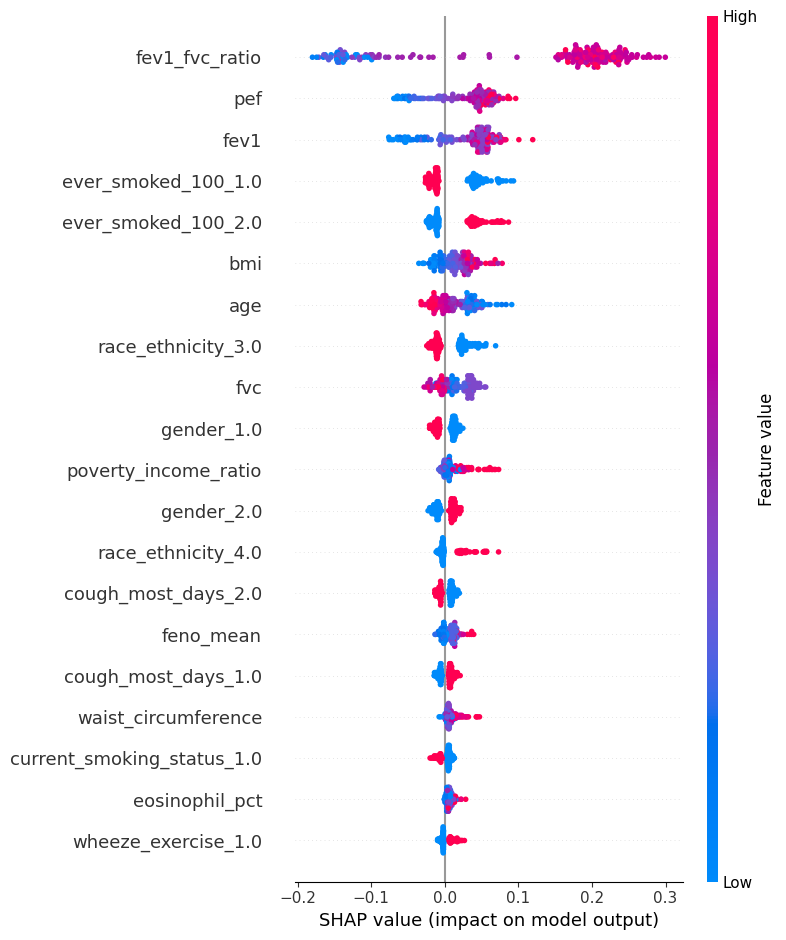


=== SHAP Local Explanations (3 example patients) ===

Patient (true=Asthma, predicted P(asthma)=0.762):
fev1_fvc_ratio        -0.093162
ever_smoked_100_1.0    0.089819
ever_smoked_100_2.0    0.079870
race_ethnicity_4.0     0.055370
race_ethnicity_3.0     0.053409

Patient (true=Asthma, predicted P(asthma)=0.985):
fev1_fvc_ratio         0.158742
pef                    0.059274
fev1                   0.055158
age                    0.036543
ever_smoked_100_2.0    0.035012

Patient (true=Asthma, predicted P(asthma)=0.968):
fev1_fvc_ratio    0.229313
pef               0.066264
fev1              0.045227
age               0.038294
fvc               0.034956


In [15]:
print("--- SHAP explainability (Random Forest) ---")
importance_df, explainer, sv, feature_names = run_shap_analysis(X, y, categorical_cols, model_name="Random Forest")